# Trophoblast: subtype DMRs, expression & flanking mCH (Fig 6I,J)

Part of the **[Fig. 2 chapter](fig2.md)** — see it for the panel-by-panel map. The first code cell sets `ENTEX_ROOT` and activates the no-overwrite guard (see the [Reproduction guide](../reproduce.md)). *Outputs shown are the author's original run.*


## 📥 Required input files

This notebook reads the following files (paths resolve from `ENTEX_ROOT`/`REF_ROOT`; the setup cell sets them). See the chapter's `inputs.md` for RAW-vs-derived tags.

- `f'{REF_ROOT}/hg38/gencode/v30/gencode.v30.annotation.gene.flat.tsv.gz'`  ·  _ref: gencode_
- `f'{indir}scRNA/{group}/{study}/{group}_{study}_ds.h5ad'`  ·  _scRNA/expr_
- `f'{outdir}bulkexpr_{study}.hdf'`  ·  _expression_
- `f'{outdir}design_{study}.hdf'`  ·  _other_
- `f'{outdir}DEG_SCT_VCT_stats.hdf'`  ·  _other_
- `f'{peak_ct}.split50.slop25kb.500b.{mc_ct.split("/")[-1]}.CGN-Merge.tsv'`  ·  _table_
- `f'{peak_ct}.split0.slop25kb.500b.{mc_ct.split("/")[-1]}.CGN-Merge.tsv'`  ·  _table_
- `f'{outdir}{group_name}_dmr.mcds'`  ·  _mC matrix (mcds)_
- `f'{outdir}celltype_dmr.closest_tss.txt'`  ·  _DMR_
- `f'{peak_ct}.split1.slop250kb.5kb.{mc_ct.split("/")[-1]}.CGN-Merge.tsv'`  ·  _table_


In [1]:
# === Reproduction setup — edit ENTEX_ROOT / REF_ROOT for your machine ===
import os, sys
ENTEX_ROOT = os.environ.get('ENTEX_ROOT', '/large_storage/zhoulab/zhoujt/project/ENTEx')
REF_ROOT   = os.environ.get('REF_ROOT',   '/large_storage/zhoulab/ref')
BOOK_ROOT  = os.environ.get('BOOK_ROOT',  f'{ENTEX_ROOT}/analysis/HumanCellEpigenomeAtlas')
sys.path.insert(0, BOOK_ROOT)
os.chdir(f'{ENTEX_ROOT}/analysis')   # original working directory
import repro_guard                    # no-overwrite guard (default: skip existing)

In [2]:
import os
import time
import numpy as np
import pandas as pd
from glob import glob
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
from concurrent.futures import ProcessPoolExecutor, as_completed

import cooler
import anndata
import scanpy as sc
import scanpy.external as sce
from sklearn.preprocessing import normalize

from ALLCools.clustering import *
from ALLCools.plot import *
from ALLCools.mcds import MCDS
from ALLCools.integration.seurat_class import SeuratIntegration

mpl.style.use('default')
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42
mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['font.sans-serif'] = 'Helvetica'


In [3]:
def dump_embedding(adata, name, n_dim=2):
    # put manifold coordinates into adata.obs
    for i in range(n_dim):
        adata.obs[f'{name}_{i}'] = adata.obsm[f'X_{name}'][:, i]
    return adata


In [4]:
chrom_size_path = f'{REF_ROOT}/hg38/fasta/hg38.main.chrom.sizes'
chrom_sizes = cooler.read_chromsizes(chrom_size_path, all_names=True)
chrom_sizes = chrom_sizes.iloc[:22]


In [5]:
def expand_bed(input_file, window_size, window, split, min_split_size):

    dist = window_size * window
    dist_str = num2str(dist)
    ws_str = num2str(window_size)
    bed = pd.read_csv(input_file, sep='\t', header=None, index_col=None, usecols=[0,1,2], names=['chrom', 'start', 'end'])
    bed = bed.loc[bed['chrom'].isin(chrom_sizes.index)]

    if split==0:
        mid = ((bed['start'] + bed['end']) // 2).astype(int)
        bed['start'], bed['end'] = mid.copy(), mid.copy()
    bed['start'] = bed['start'] - dist
    bed['end'] = bed['end'] + dist
    bed = bed.loc[(bed['start']>0) & (bed['end']<bed['chrom'].map(chrom_sizes))]
    
    bed_new = []
    for idx,xx,yy,zz in bed.reset_index().values:
        if split>0:
            split_size = (zz-yy-2*dist) / split
            if split_size<min_split_size:
                continue
        for i in range(window):
            bed_new.append([xx, yy+window_size*i, yy+window_size*(i+1), f'{idx}_{i}'])
        # if (yy+dist)<(zz-dist):
        #     bed_new.append([xx, yy+dist, zz-dist])
        if split>0:
            for i in range(split):
                bed_new.append([xx, yy+dist+split_size*i, yy+dist+split_size*(i+1), f'{idx}_{window+i}'])
        for i in range(window):
            bed_new.append([xx, zz-dist+window_size*i, zz-dist+window_size*(i+1), f'{idx}_{window+split+i}'])

    print(len(bed_new))
    bed_new = pd.DataFrame(bed_new)
    bed_new[[1,2]] = np.around(bed_new[[1,2]], decimals=0).astype(int)
    bed_new.to_csv(input_file.replace('.bed',f'.split{split}.slop{dist_str}b.{ws_str}b.bed'), sep='\t', header=False, index=False)
    return dist_str, ws_str


In [6]:
def num2str(num):
    if num>=1e6:
        num_str = f'{int(num//1e6)}m'
    elif num>=1e3:
        num_str = f'{int(num//1e3)}k'
    else:
        num_str = f'{num}'
    return num_str
        
def generate_flankmap(peak_group, mc_group, window_size=500, window=50, split=0, min_split_size=1):
    dist_str, ws_str = expand_bed(f'{peak_group}.bed', window_size=window_size, window=window, split=split, min_split_size=min_split_size)
    time.sleep(3)
    cmd = f'bigWigAverageOverBed {mc_group}.CGN-Merge.frac.bw {peak_group}.split{split}.slop{dist_str}b.{ws_str}b.bed {peak_group}.split{split}.slop{dist_str}b.{ws_str}b.{mc_group.split("/")[-1]}.CGN-Merge.tsv'
    os.system(cmd)
    return


In [7]:
indir = f'{ENTEX_ROOT}/'
outdir = f'{ENTEX_ROOT}/analysis/PMD_RNA/Epi-TPB/'


In [8]:
group = 'Placenta'
study = 'Arutyunyan2023'


In [9]:
group_name = 'Epi-TPB'

In [10]:
gene_meta = pd.read_csv(f'{REF_ROOT}/hg38/gencode/v30/gencode.v30.annotation.gene.flat.tsv.gz', sep='\t', header=0)
gene_meta['gene_id_idx'] = gene_meta['gene_id'].str.split('.').str[0]

In [11]:
ens2gene = gene_meta.set_index('gene_id_idx')['gene_name'].to_dict()
gene2ens = gene_meta.set_index('gene_name')['gene_id_idx'].to_dict()


In [12]:
adata = anndata.read_h5ad(f'{indir}scRNA/{group}/{study}/{group}_{study}_ds.h5ad')
adata

In [13]:
marker = pd.Index(['TP63', 'KAZN', 'PRDM2', 'TNFRSF1B', 'SH2D5', 'PAFAH2', 'EXTL1', 'NCMAP'])
marker = marker[marker.isin(gene2ens)]
marker

In [14]:
adata.obs['total_counts'] = adata.raw.X.sum(axis=1).A1

In [15]:
marker_expr = pd.DataFrame(adata.raw[:, marker.map(gene2ens)].X.toarray(), index=adata.obs.index, columns=marker)
marker_expr = marker_expr / adata.obs['total_counts'].values[:, None]
marker_expr = np.log1p(marker_expr)


In [16]:
ds = 0.5
coord_base = 'tsne'
# adata.obsm[f'X_{coord_base}'] = adata.obsm[f'RNA_pc{npc}hm_{coord_base}'].copy()
# dump_embedding(adata, coord_base)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), dpi=300, constrained_layout=True)

tmp = adata.obs.copy()
for j,yy in enumerate(['celltype', 'batch']):
    ax = axes[j]
    ax.scatter(adata.obs['tsne_0'], adata.obs['tsne_1'], s=ds, edgecolor='none', rasterized=True, color=(0.8,0.8,0.8))
    _ = categorical_scatter(data=tmp,
                            ax=ax,
                            coord_base=coord_base,
                            hue=yy,
                            # text_anno=yy,
                            labelsize=6,
                            s=ds*2,
                            palette='tab20',
                            scatter_kws={'rasterized':True},
                            # legend_kws={'ncol':1},
                            show_legend=True
                           )
ax.set_title(study, fontsize=12)


In [17]:
ncol = 4
nrow = (len(marker) - 1) // ncol + 1

fig, axes = plt.subplots(nrow, ncol, figsize=(4*ncol,3*nrow), dpi=300, constrained_layout=True)
tmp = adata.obs.copy()
for i,k in enumerate(marker):
    ax = axes.flatten()[i]
    ax.set_title(k, fontsize=12)
    _ = continuous_scatter(data=tmp,
                           ax=ax,
                           coord_base=coord_base,
                           hue=marker_expr[k],
                           s=ds,
                           labelsize=12,
                           max_points=None,
                           scatter_kws={'rasterized':True},
                           # hue_norm=[vmin, vmax],
                          )
    
for ax in axes.flatten()[len(marker):]:
    ax.axis('off')


In [18]:
leg = {'EVT': ['EVT_1', 'EVT_2', 'eEVT', 'iEVT', 'GC'], 
       'VCT': ['VCT', 'VCT_p'], 
       'SCT': ['SCT'],
       'VCT_other': ['VCT_CCC', 'VCT_fusing']}


In [19]:
design = []
expr = []
for indiv in np.sort(adata.obs['batch'].unique()):
    for group in leg:
        tmp = adata.raw.X[(adata.obs['batch']==indiv) & adata.obs['celltype'].isin(leg[group])].sum(axis=0).A1
        expr.append(tmp)
        design.append([indiv, group])
            
design = pd.DataFrame(design, columns=['donor', 'celltype'])
expr = pd.DataFrame(expr, columns=adata.raw.var.index)


In [20]:
expr = expr.loc[:, expr.columns.isin(gene_meta['gene_id_idx'])]

In [21]:
expr.to_hdf(f'{outdir}bulkexpr_{study}.hdf', key='data')
design.to_hdf(f'{outdir}design_{study}.hdf', key='data')


In [22]:
expr = pd.read_hdf(f'{outdir}bulkexpr_{study}.hdf', key='data')
design = pd.read_hdf(f'{outdir}design_{study}.hdf', key='data')


In [23]:
gene_meta['TSS'] = gene_meta['start'].copy()
selg = (gene_meta['strand']=='-')
gene_meta.loc[selg, 'TSS'] = gene_meta.loc[selg, 'end']
gene_meta['length'] = gene_meta['end'] - gene_meta['start']


In [24]:
tmp = gene_meta.set_index('gene_id_idx').loc[expr.columns]

In [25]:
sels = design.loc[design['celltype'].isin(['SCT', 'VCT'])].sort_values('celltype').index
exprtmp = expr.loc[sels]
designtmp = design.loc[sels]


In [26]:
from pydeseq2.dds import DeseqDataSet
from pydeseq2.default_inference import DefaultInference
from pydeseq2.ds import DeseqStats
from pydeseq2.utils import load_example_data

from statsmodels.stats.multitest import multipletests as FDR


In [27]:
genes_to_keep = exprtmp.columns[exprtmp.sum(axis=0) >= 10]
counts_df = exprtmp[genes_to_keep]
inference = DefaultInference(n_cpus=8)
dds = DeseqDataSet(
    counts=counts_df,
    metadata=designtmp,
    design_factors=['donor', 'celltype'],
    refit_cooks=True,
    inference=inference,
    # n_cpus=8, # n_cpus can be specified here or in the inference object
)
dds.deseq2()
stat_res = DeseqStats(dds, contrast=['celltype', 'SCT', 'VCT'], inference=inference)
stat_res.summary()
stat_res.results_df.to_hdf(f'{outdir}DEG_SCT_VCT_stats.hdf', key='data')
deg_stats = stat_res.results_df.copy()


In [28]:
deg_stats = pd.read_hdf(f'{outdir}DEG_SCT_VCT_stats.hdf', key='data')
deg_stats['pvalue'] = deg_stats['pvalue'].fillna(1)
deg_stats['fdr'] = FDR(deg_stats['pvalue'], alpha=0.05, method='fdr_bh')[1]


In [29]:
tmp = deg_stats.copy()
fig, ax = plt.subplots(figsize=(4,3), dpi=300)
selc = (np.abs(tmp['log2FoldChange'])>1) & (tmp['fdr']<1e-5)
ax.scatter(tmp.loc[~selc, 'log2FoldChange'], -np.log10(tmp.loc[~selc, 'fdr']), s=0.1, c='k', edgecolor='none')
ax.scatter(tmp.loc[selc, 'log2FoldChange'], -np.log10(tmp.loc[selc, 'fdr']), s=0.5, c='r', edgecolor='none')
ax.set_xlabel('log2FC SCT/VCT')
ax.set_ylabel('-log10 FDR')
print(selc.sum())


In [30]:
deg1 = deg_stats.index[(deg_stats['log2FoldChange']>1) & (deg_stats['fdr']<1e-5)]
deg2 = deg_stats.index[(deg_stats['log2FoldChange']<-1) & (deg_stats['fdr']<1e-5)]


In [31]:
tmp = gene_meta.set_index('gene_id_idx').loc[deg1].sort_values(['chrom', 'start', 'end']).reset_index()[['chrom','start','end', 'index', 'gene_name', 'strand']]
tmp.to_csv(f'{outdir}{group_name}_SCTgene.bed', sep='\t', header=None, index=None)
deg1 = tmp.index.copy()
tmp = gene_meta.set_index('gene_id_idx').loc[deg2].sort_values(['chrom', 'start', 'end']).reset_index()[['chrom','start','end', 'index', 'gene_name', 'strand']]
tmp.to_csv(f'{outdir}{group_name}_VCTgene.bed', sep='\t', header=None, index=None)
deg2 = tmp.index.copy()


In [32]:
# dmr_list = np.sort(glob(f'{outdir}*gene.bed'))
# dmr_list = np.sort([xx.replace('.bed', '') for xx in dmr_list])
dmr_list = np.array([f'{outdir}hg38_20kbin', f'{outdir}gene', 
                     f'{outdir}{group_name}_SCTgene', 
                     f'{outdir}{group_name}_VCTgene',
                    ])

bw_list = glob(f'{indir}analysis/PMD_DMR/Epi-TPB/*.frac.bw')
bw_list = np.sort([xx.replace('.CGN-Merge.frac.bw', '') for xx in bw_list])

print(dmr_list, bw_list)


In [33]:
cpu = 32
with ProcessPoolExecutor(cpu) as executor:
    futures = {}
    for peak_ct in dmr_list:
        for mc_ct in bw_list:
            future = executor.submit(
                generate_flankmap,
                peak_group=peak_ct,
                mc_group=mc_ct,
                window_size=500, window=50, split=50, min_split_size=1
            )
            futures[future] = f'{peak_ct}-{mc_ct}'
    result = {}
    for future in as_completed(futures):
        ct = futures[future]
        result[ct] = future.result()
        print(f'{ct} finished')
        

In [34]:
ave_list = []
data_list = []
for i,peak_ct in enumerate(dmr_list):
    ave_tmp = []
    data_tmp = []
    bed = pd.read_csv(f'{peak_ct}.bed', sep='\t', index_col=3, header=None)
    for j,mc_ct in enumerate(bw_list):
        data = pd.read_csv(f'{peak_ct}.split50.slop25kb.500b.{mc_ct.split("/")[-1]}.CGN-Merge.tsv', sep='\t', header=None, index_col=0)
        ratio = data[5].values.reshape((-1, 150))
        cov = data[2].values.reshape((-1, 150))
        print((cov==0).sum() / cov.shape[0] / cov.shape[1])
        if j==0:
            idx = data.index.str.split('_').str[0].astype(int).unique()
            idx = bed.index[idx]
            binfilter = pd.Index((cov>0).sum(axis=1)) > (0.5*cov.shape[1])
        else:
            binfilter &= pd.Index((cov>0).sum(axis=1) > (0.5*cov.shape[1]))
        if bed.shape[1]==5:
            ratio[bed.loc[idx, 5]=='-'] = ratio[bed.loc[idx, 5]=='-'][:, ::-1]
        ratio[cov==0] = np.nan
        data_tmp.append(pd.DataFrame(ratio, index=idx))
    print(binfilter.sum(), binfilter.shape[0])
    ave_tmp = [np.nanmean(data[binfilter], axis=0) for data in data_tmp]
    data_tmp = [data[binfilter].fillna(1) for data in data_tmp]
    ave_list.append(ave_tmp)
    data_list.append(data_tmp)


In [35]:
titles = ['Bins', 'All', 'SCT', 'VCT']

fig, axes = plt.subplots(1, 4, figsize=(10,2), dpi=300, sharey='all', sharex='all')
for i,peak_ct in enumerate(dmr_list):
    ax = axes[i]
    for j,mc_ct in enumerate(bw_list):
        ax.plot(np.arange(150), ave_list[i][j], color=plt.cm.tab20(j), 
                label=mc_ct.split('/')[-1], linewidth=1, alpha=0.8)
    ax.set_title(f'{titles[i]} gene')

ax.set_xlim([-0.5, 149.5])
ax.set_ylim([0.2, 0.8])
ax.set_xticks([-0.5, 49.5, 99.5, 149.5])
ax.set_xticklabels(['-25k', 'TSS', 'TES', '+25k'])
ax.legend(bbox_to_anchor=(1,1))

fig.tight_layout()
# fig.savefig(f'{outdir}{group_name}_DMR_flank_lineplot.pdf', transparent=True)


In [36]:
titles = ['Bins', 'All', 'SCT', 'VCT']
fig, axes = plt.subplots(4, 4, figsize=(8,8), dpi=300, sharey='row')
for i,peak_ct in enumerate(dmr_list):
    for j,mc_ct in enumerate(bw_list):
        ax = axes[i,j]
        ratio = data_list[i][j].values
        idx = np.argsort(ratio[:, 50:100].mean(axis=1))
        if j==0:
            ax.set_ylabel(f'{ratio.shape[0]} {titles[i]} gene')
        ax.imshow(ratio[idx], cmap='jet', vmin=0, vmax=1.0, aspect='auto', 
                  interpolation='none', rasterized=True)
        ax.set_yticks([])
        ax.set_xlim([-0.5, 149.5])
        ax.set_xticks([-0.5, 49.5, 99.5, 149.5])
        ax.set_xticklabels(['-25k', 'TSS', 'TES', '+25k'])
        if i==0:
            ax.set_title(f'{mc_ct.split("/")[-1]}')
                
fig.tight_layout()
# fig.savefig(f'{outdir}{group_name}_DMR_flank_heatmap.pdf', transparent=True)


In [37]:
tmp = gene_meta.set_index('gene_id_idx').loc[deg1].sort_values(['chrom', 'TSS']).reset_index()[['chrom','TSS','TSS', 'index', 'gene_name', 'strand']]
tmp.to_csv(f'{outdir}{group_name}_SCTtss.bed', sep='\t', header=None, index=None)
deg1 = tmp.index.copy()
tmp = gene_meta.set_index('gene_id_idx').loc[deg2].sort_values(['chrom', 'TSS']).reset_index()[['chrom','TSS','TSS', 'index', 'gene_name', 'strand']]
tmp.to_csv(f'{outdir}{group_name}_VCTtss.bed', sep='\t', header=None, index=None)
deg2 = tmp.index.copy()


In [38]:
# dmr_list = np.sort(glob(f'{outdir}*gene.bed'))
# dmr_list = np.sort([xx.replace('.bed', '') for xx in dmr_list])
dmr_list = np.array([f'{outdir}hg38_20kbin', f'{outdir}tss', 
                     f'{outdir}{group_name}_SCTtss', 
                     f'{outdir}{group_name}_VCTtss',
                    ])

bw_list = glob(f'{indir}analysis/PMD_DMR/Epi-TPB/*.frac.bw')
bw_list = np.sort([xx.replace('.CGN-Merge.frac.bw', '') for xx in bw_list])

print(dmr_list, bw_list)


In [39]:
cpu = 32
with ProcessPoolExecutor(cpu) as executor:
    futures = {}
    for peak_ct in dmr_list:
        for mc_ct in bw_list:
            future = executor.submit(
                generate_flankmap,
                peak_group=peak_ct,
                mc_group=mc_ct,
                window_size=500, window=50, split=0, min_split_size=1
            )
            futures[future] = f'{peak_ct}-{mc_ct}'
    result = {}
    for future in as_completed(futures):
        ct = futures[future]
        result[ct] = future.result()
        print(f'{ct} finished')
        

In [40]:
ave_list = []
data_list = []
for i,peak_ct in enumerate(dmr_list):
    ave_tmp = []
    data_tmp = []
    bed = pd.read_csv(f'{peak_ct}.bed', sep='\t', index_col=3, header=None)
    for j,mc_ct in enumerate(bw_list):
        data = pd.read_csv(f'{peak_ct}.split0.slop25kb.500b.{mc_ct.split("/")[-1]}.CGN-Merge.tsv', sep='\t', header=None, index_col=0)
        ratio = data[5].values.reshape((-1, 100))
        cov = data[2].values.reshape((-1, 100))
        print((cov==0).sum() / cov.shape[0] / cov.shape[1])
        if j==0:
            idx = data.index.str.split('_').str[0].astype(int).unique()
            idx = bed.index[idx]
            binfilter = pd.Index((cov>0).sum(axis=1)) > (0.5*cov.shape[1])
        else:
            binfilter &= pd.Index((cov>0).sum(axis=1) > (0.5*cov.shape[1]))
        if bed.shape[1]==5:
            ratio[bed.loc[idx, 5]=='-'] = ratio[bed.loc[idx, 5]=='-'][:, ::-1]
        ratio[cov==0] = np.nan
        data_tmp.append(pd.DataFrame(ratio, index=idx))
    print(binfilter.sum(), binfilter.shape[0])
    ave_tmp = [np.nanmean(data[binfilter], axis=0) for data in data_tmp]
    data_tmp = [data[binfilter].fillna(1) for data in data_tmp]
    ave_list.append(ave_tmp)
    data_list.append(data_tmp)


In [41]:
titles = ['Bins', 'All', 'SCT', 'VCT']

fig, axes = plt.subplots(1, 4, figsize=(10,2), dpi=300, sharey='all', sharex='all')
for i,peak_ct in enumerate(dmr_list):
    ax = axes[i]
    for j,mc_ct in enumerate(bw_list):
        ax.plot(np.arange(100), ave_list[i][j], color=plt.cm.tab20(j), 
                label=mc_ct.split('/')[-1], linewidth=1, alpha=0.8)
    ax.set_title(f'{titles[i]} gene')

ax.set_xlim([-0.5, 99.5])
ax.set_ylim([0.1, 0.8])
ax.set_xticks([-0.5, 49.5, 99.5])
ax.set_xticklabels(['-25k', 'TSS', '+25k'])
ax.legend(bbox_to_anchor=(1,1))

fig.tight_layout()
# fig.savefig(f'{outdir}{group_name}_DMR_flank_lineplot.pdf', transparent=True)


In [42]:
titles = ['Bins', 'All', 'SCT', 'VCT']
fig, axes = plt.subplots(4, 4, figsize=(8,8), dpi=300, sharey='row')
for i,peak_ct in enumerate(dmr_list):
    for j,mc_ct in enumerate(bw_list):
        ax = axes[i,j]
        ratio = data_list[i][j].values
        idx = np.argsort(ratio.mean(axis=1))
        if j==0:
            ax.set_ylabel(f'{ratio.shape[0]} {titles[i]} gene')
        ax.imshow(ratio[idx], cmap='jet', vmin=0, vmax=1.0, aspect='auto', 
                  interpolation='none', rasterized=True)
        ax.set_yticks([])
        ax.set_xlim([-0.5, 99.5])
        ax.set_xticks([-0.5, 49.5, 99.5])
        ax.set_xticklabels(['-25k', 'TSS', '+25k'])
        if i==0:
            ax.set_title(f'{mc_ct.split("/")[-1]}')
                
fig.tight_layout()
# fig.savefig(f'{outdir}{group_name}_DMR_flank_heatmap.pdf', transparent=True)


In [43]:
ave_list = []
data_list = []
for i,peak_ct in enumerate(dmr_list):
    ave_tmp = []
    data_tmp = []
    deg = [deg1, deg2][i]
    for j,mc_ct in enumerate(bw_list):
        data = pd.read_csv(f'{peak_ct}.split50.slop25kb.500b.{mc_ct.split("/")[-1]}.CGN-Merge.tsv', sep='\t', header=None, index_col=0)
        ratio = data[5].values.reshape((-1, 150))
        cov = data[2].values.reshape((-1, 150))
        print((cov==0).sum() / cov.shape[0] / cov.shape[1])
        if j==0:
            idx = data.index.str.split('_').str[0].astype(int).unique()
            deg = deg[idx]
            genetmp = gene_meta.set_index('gene_id_idx').loc[deg]
            ## without length filter
            # idx = genetmp['length'].sort_values().index
            selg = (genetmp['length']>5000)
            ## sort by length
            # idx = genetmp.loc[selg, 'length'].sort_values().index
            deg = deg[selg]
            ## sort by fc
            # idx = deg_stats.loc[deg, 'log2FoldChange'].sort_values().index
            ## sort by flank mc
            idx = pd.Index(deg[np.argsort(ratio[selg].sum(axis=1) - ratio[selg, 50:100].sum(axis=1))])
        ratio[genetmp['strand']=='-'] = ratio[genetmp['strand']=='-'][:, ::-1]
        ratio = ratio[selg]
        cov = cov[selg]
        ave_tmp.append(np.nanmean(ratio, axis=0))
        ratio[cov==0] = 1.0
        data_tmp.append(pd.DataFrame(ratio, index=deg).loc[idx])
    ave_list.append(ave_tmp)
    data_list.append(data_tmp)
    

In [44]:
titles = ['SCT', 'VCT']

fig, axes = plt.subplots(1, 2, figsize=(5,2), dpi=300, sharey='all', sharex='all')
for i,peak_ct in enumerate(dmr_list):
    ax = axes[i]
    for j,mc_ct in enumerate(bw_list):
        ax.plot(np.arange(150), ave_list[i][j], color=plt.cm.tab20(j), 
                label=mc_ct.split('/')[-1], linewidth=1, alpha=0.8)
    ax.set_title(f'{titles[i]} gene')

ax.set_xlim([-0.5, 149.5])
ax.set_ylim([0.2, 0.8])
ax.set_xticks([-0.5, 49.5, 99.5, 149.5])
ax.set_xticklabels(['-25k', 'TSS', 'TES', '+25k'])
ax.legend(bbox_to_anchor=(1,1))

fig.tight_layout()
# fig.savefig(f'{outdir}{group_name}_DMR_flank_lineplot.pdf', transparent=True)


In [45]:
titles = ['SCT', 'VCT']
fig, axes = plt.subplots(2, 4, figsize=(8,4), dpi=300, sharey='row')
for i,peak_ct in enumerate(dmr_list):
    for j,mc_ct in enumerate(bw_list):
        ax = axes[i,j]
        ratio = data_list[i][j]
        if j==0:
            ax.set_ylabel(f'{ratio.shape[0]} {titles[i]} gene')
        ax.imshow(ratio, cmap='jet', vmin=0, vmax=1.0, aspect='auto', 
                  interpolation='none', rasterized=True)
        ax.set_yticks([])
        ax.set_xlim([-0.5, 149.5])
        ax.set_xticks([-0.5, 49.5, 99.5, 149.5])
        ax.set_xticklabels(['-25k', 'TSS', 'TES', '+25k'])
        if i==0:
            ax.set_title(f'{mc_ct.split("/")[-1]}')
                
fig.tight_layout()
# fig.savefig(f'{outdir}{group_name}_DMR_flank_heatmap.pdf', transparent=True)


In [46]:
titles = ['SCT', 'VCT']
fig, axes = plt.subplots(2, 4, figsize=(8,4), dpi=300, sharey='row')
for i,peak_ct in enumerate(dmr_list):
    for j,mc_ct in enumerate(bw_list):
        ax = axes[i,j]
        ratio = data_list[i][j]
        if j==0:
            ax.set_ylabel(f'{ratio.shape[0]} {titles[i]} gene')
        ax.imshow(ratio, cmap='jet', vmin=0, vmax=1.0, aspect='auto', 
                  interpolation='none', rasterized=True)
        ax.set_yticks([])
        ax.set_xlim([-0.5, 149.5])
        ax.set_xticks([-0.5, 49.5, 99.5, 149.5])
        ax.set_xticklabels(['-25k', 'TSS', 'TES', '+25k'])
        if i==0:
            ax.set_title(f'{mc_ct.split("/")[-1]}')
                
fig.tight_layout()
# fig.savefig(f'{outdir}{group_name}_DMR_flank_heatmap.pdf', transparent=True)


In [47]:
titles = ['SCT', 'VCT']
fig, axes = plt.subplots(2, 4, figsize=(8,4), dpi=300, sharey='row')
for i,peak_ct in enumerate(dmr_list):
    for j,mc_ct in enumerate(bw_list):
        ax = axes[i,j]
        ratio = data_list[i][j]
        if j==0:
            ax.set_ylabel(f'{ratio.shape[0]} {titles[i]} gene')
        ax.imshow(ratio, cmap='jet', vmin=0, vmax=1.0, aspect='auto', 
                  interpolation='none', rasterized=True)
        ax.set_yticks([])
        ax.set_xlim([-0.5, 149.5])
        ax.set_xticks([-0.5, 49.5, 99.5, 149.5])
        ax.set_xticklabels(['-25k', 'TSS', 'TES', '+25k'])
        if i==0:
            ax.set_title(f'{mc_ct.split("/")[-1]}')
                
fig.tight_layout()
# fig.savefig(f'{outdir}{group_name}_DMR_flank_heatmap.pdf', transparent=True)


In [48]:
deg1 = deg_stats.index[(deg_stats['log2FoldChange']>1) & (deg_stats['fdr']<1e-5)]
deg2 = deg_stats.index[(deg_stats['log2FoldChange']<-1) & (deg_stats['fdr']<1e-5)]


In [49]:
tmp = gene_meta.set_index('gene_id_idx').loc[deg1].sort_values(['chrom', 'TSS'])[['chrom','TSS']]
# tmp['start'] = tmp['TSS'] - 1
tmp[['chrom', 'TSS', 'TSS']].to_csv(f'{outdir}{group_name}_SCTtss.bed', sep='\t', header=None, index=None)
deg1 = tmp.index.copy()
tmp = gene_meta.set_index('gene_id_idx').loc[deg2].sort_values(['chrom', 'TSS'])[['chrom','TSS']]
# tmp['start'] = tmp['TSS'] - 1
tmp[['chrom', 'TSS', 'TSS']].to_csv(f'{outdir}{group_name}_VCTtss.bed', sep='\t', header=None, index=None)
deg2 = tmp.index.copy()


In [50]:
dmr_list = np.sort(glob(f'{outdir}*tss.bed'))
dmr_list = np.sort([xx.replace('.bed', '') for xx in dmr_list])

bw_list = glob(f'{indir}analysis/PMD_DMR/Epi-TPB/*.frac.bw')
bw_list = np.sort([xx.replace('.CGN-Merge.frac.bw', '') for xx in bw_list])

print(dmr_list, bw_list)


In [51]:
cpu = 32
with ProcessPoolExecutor(cpu) as executor:
    futures = {}
    for peak_ct in dmr_list:
        for mc_ct in bw_list:
            future = executor.submit(
                generate_flankmap,
                peak_group=peak_ct,
                mc_group=mc_ct,
                window_size=500, window=50, split=0, min_split_size=1
            )
            futures[future] = f'{peak_ct}-{mc_ct}'
    result = {}
    for future in as_completed(futures):
        ct = futures[future]
        result[ct] = future.result()
        print(f'{ct} finished')
        

In [52]:
ave_list = []
data_list = []
for i,peak_ct in enumerate(dmr_list):
    ave_tmp = []
    data_tmp = []
    deg = [deg1, deg2][i]
    for j,mc_ct in enumerate(bw_list):
        data = pd.read_csv(f'{peak_ct}.split0.slop25kb.500b.{mc_ct.split("/")[-1]}.CGN-Merge.tsv', sep='\t', header=None, index_col=0)
        ratio = data[5].values.reshape((-1, 100))
        cov = data[2].values.reshape((-1, 100))
        print((cov==0).sum() / cov.shape[0] / cov.shape[1])
        if j==0:
            idx = data.index.str.split('_').str[0].astype(int).unique()
            deg = deg[idx]
            genetmp = gene_meta.set_index('gene_id_idx').loc[deg]
            ## sort by length
            # idx = genetmp['length'].sort_values().index
            ## sort by fc
            idx = deg_stats.loc[deg, 'log2FoldChange'].sort_values().index
            # selg = (genetmp['length']>5000)
            # idx = genetmp.loc[selg, 'length'].sort_values().index
            # deg = deg[selg]
        ratio[genetmp['strand']=='-'] = ratio[genetmp['strand']=='-'][:, ::-1]
        # ratio = ratio[selg]
        # cov = cov[selg]
        # deg = deg[selg]
        ave_tmp.append(np.nanmean(ratio, axis=0))
        ratio[cov==0] = 1.0
        data_tmp.append(pd.DataFrame(ratio, index=deg).loc[idx])
    ave_list.append(ave_tmp)
    data_list.append(data_tmp)
    

In [53]:
titles = ['SCT', 'VCT']

fig, axes = plt.subplots(1, 2, figsize=(5,2), dpi=300, sharey='all', sharex='all')
for i,peak_ct in enumerate(dmr_list):
    ax = axes[i]
    for j,mc_ct in enumerate(bw_list):
        ax.plot(np.arange(100), ave_list[i][j], color=plt.cm.tab20(j), 
                label=mc_ct.split('/')[-1], linewidth=1, alpha=0.8)
    ax.set_title(f'{titles[i]} gene')

ax.set_xlim([-0.5, 99.5])
ax.set_ylim([0.1, 0.8])
ax.set_xticks([-0.5, 49.5, 99.5])
ax.set_xticklabels(['-25k', 'TSS', '+25k'])
ax.legend(bbox_to_anchor=(1,1))

fig.tight_layout()
# fig.savefig(f'{outdir}{group_name}_DMR_flank_lineplot.pdf', transparent=True)


In [54]:
titles = ['SCT', 'VCT']
fig, axes = plt.subplots(2, 4, figsize=(8,4), dpi=300, sharey='row')
for i,peak_ct in enumerate(dmr_list):
    for j,mc_ct in enumerate(bw_list):
        ax = axes[i,j]
        ratio = data_list[i][j]
        if j==0:
            ax.set_ylabel(f'{ratio.shape[0]} {titles[i]} gene')
        ax.imshow(ratio, cmap='jet', vmin=0, vmax=1.0, aspect='auto', 
                  interpolation='none', rasterized=True)
        ax.set_yticks([])
        ax.set_xlim([-0.5, 99.5])
        ax.set_xticks([-0.5, 49.5, 99.5])
        ax.set_xticklabels(['-25k', 'TSS', '+25k'])
        if i==0:
            ax.set_title(f'{mc_ct.split("/")[-1]}')
                
fig.tight_layout()
# fig.savefig(f'{outdir}{group_name}_DMR_flank_heatmap.pdf', transparent=True)


In [55]:
titles = ['SCT', 'VCT']
fig, axes = plt.subplots(2, 4, figsize=(8,4), dpi=300, sharey='row')
for i,peak_ct in enumerate(dmr_list):
    for j,mc_ct in enumerate(bw_list):
        ax = axes[i,j]
        ratio = data_list[i][j]
        if j==0:
            ax.set_ylabel(f'{ratio.shape[0]} {titles[i]} gene')
        ax.imshow(ratio, cmap='jet', vmin=0, vmax=1.0, aspect='auto', 
                  interpolation='none', rasterized=True)
        ax.set_yticks([])
        ax.set_xlim([-0.5, 99.5])
        ax.set_xticks([-0.5, 49.5, 99.5])
        ax.set_xticklabels(['-25k', 'TSS', '+25k'])
        if i==0:
            ax.set_title(f'{mc_ct.split("/")[-1]}')
                
fig.tight_layout()
# fig.savefig(f'{outdir}{group_name}_DMR_flank_heatmap.pdf', transparent=True)


In [56]:
idx_list, both_list, data_list = [], [], []

In [57]:
outdir = f'{ENTEX_ROOT}/analysis/PMD_DMR/Epi-TPB/'
mcds = MCDS.open(f'{outdir}{group_name}_dmr.mcds', var_dim='celltype_dmr')
mcds

In [58]:
mc = mcds.sel({'count_type':'mc'})['celltype_dmr_da'].to_pandas()
cov = mcds.sel({'count_type':'cov'})['celltype_dmr_da'].to_pandas()
data = (mc / cov).fillna(1).T


In [59]:
data.columns = data.columns.str.replace('PVT','SCT')

In [60]:
diff1 = data['SCT-9213'] - data['VCT-9213']
diff2 = data['SCT-9216'] - data['VCT-9216']
hypo_both = (diff1 > 0.25) & (diff2 > 0.25)
hyper_both = (diff1 < -0.25) & (diff2 < -0.25)
both_dmr = (np.abs(diff1) > 0.25) & (np.abs(diff2) > 0.25)
any_dmr = (np.abs(diff1) > 0.25) | (np.abs(diff2) > 0.25)
print(both_dmr.sum() / any_dmr.sum(), any_dmr.sum() / any_dmr.shape[0])


In [61]:
idx_list.append(diff1[np.abs(diff1) > 0.25].sort_values().index)
idx_list.append(diff2[np.abs(diff2) > 0.25].sort_values().index)
both_list += [hypo_both, hyper_both]
data_list.append(data.loc[any_dmr])


In [62]:
closest_gene = pd.read_csv(f'{outdir}celltype_dmr.closest_tss.txt', sep='\t', header=None, index_col=None)
closest_gene

In [63]:
seldmr = data.index[both_dmr]
selg = deg_stats.index[(np.abs(deg_stats['log2FoldChange'])>1) & (deg_stats['fdr']<1e-5)]
dmr_gene_map = closest_gene.set_index(3)[7]
dmr_gene_map = dmr_gene_map.loc[dmr_gene_map.index.isin(seldmr) & dmr_gene_map.isin(selg)]


In [64]:
rorder = cg.dendrogram_row.reordered_ind.copy()
corder = cg.dendrogram_col.reordered_ind.copy()[::-1]


In [65]:
exprtmp = exprtmp / exprtmp.sum(axis=1).values[:, None] * 1e6

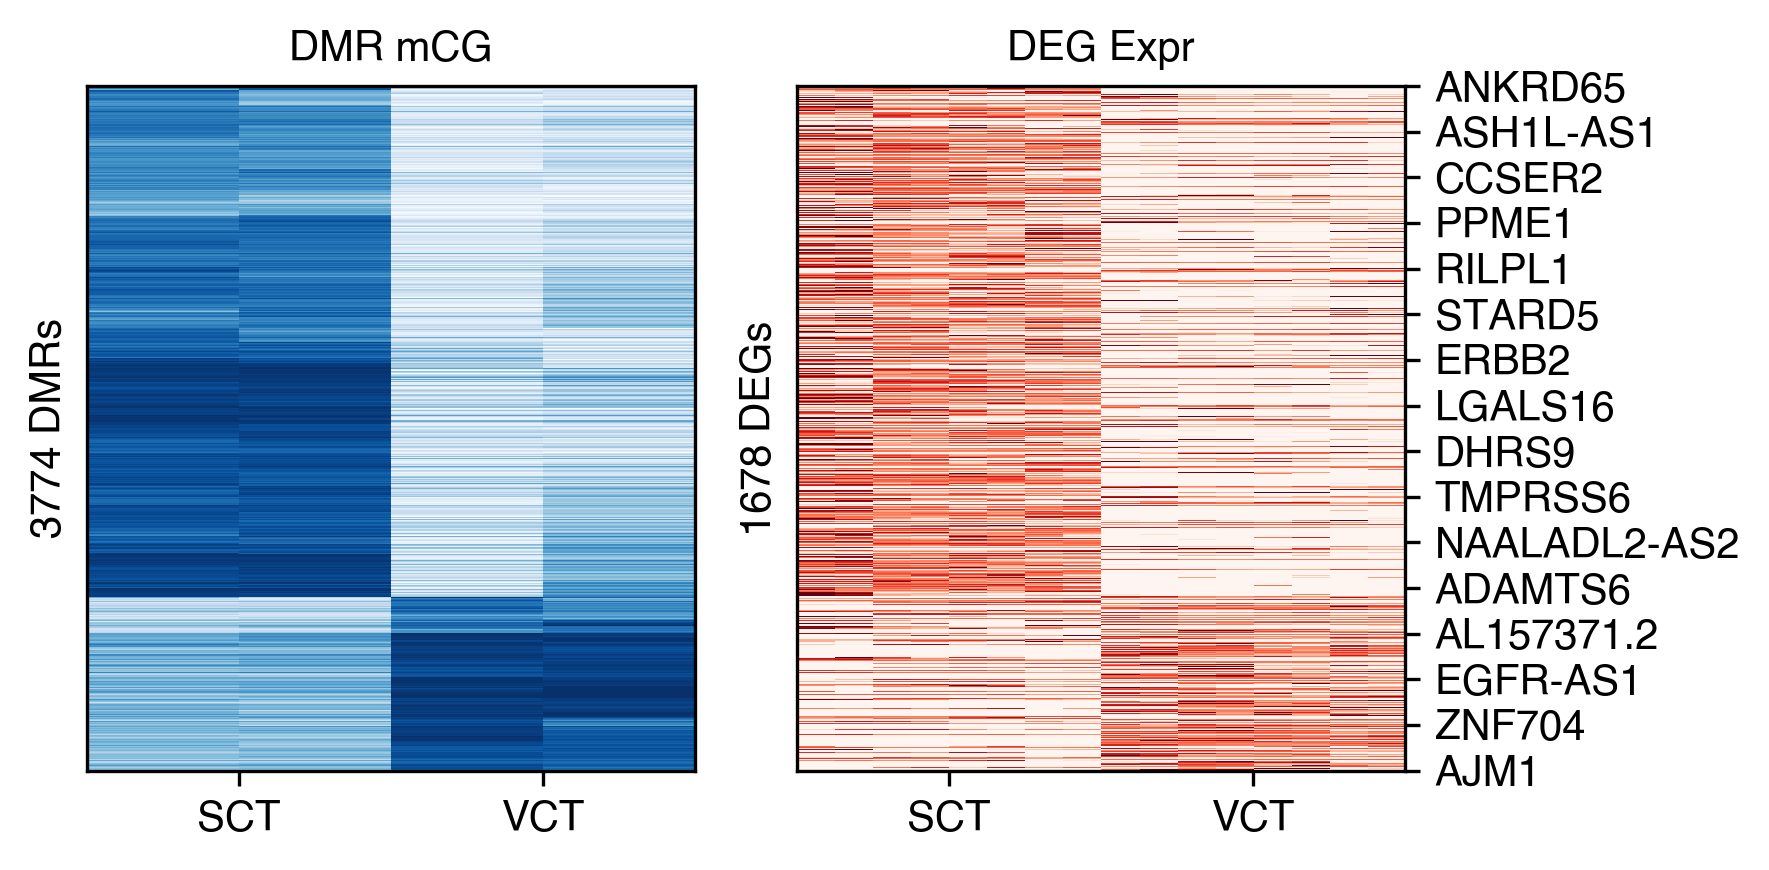

In [66]:
from scipy.stats import zscore
nrow = dmr_gene_map.shape[0]
print(nrow)

fig, axes = plt.subplots(1, 2, figsize=(6,3), dpi=300)

ax = axes[0]
ax.imshow(data.loc[dmr_gene_map.index].iloc[rorder].iloc[:, corder], 
          cmap='Blues_r', aspect='auto', interpolation='none', rasterized=True)
ax.set_title('DMR mCG', fontsize=10)
# sns.despine(ax=ax, left=True, bottom=True)
# ax.set_xticks(np.arange(data.shape[1]))
# ax.set_xticklabels(data.columns[corder], rotation=90)
ax.set_xticks([0.5, 2.5])
ax.set_xticklabels(['SCT', 'VCT'])
ax.set_yticks([])
ax.set_ylabel(f'{dmr_gene_map.index.unique().shape[0]} DMRs')

ax = axes[1]
ax.imshow(zscore(exprtmp.T.loc[dmr_gene_map.values].iloc[rorder], axis=1), 
          cmap='Reds', vmin=0, vmax=2, aspect='auto', interpolation='none', rasterized=True)
ax.set_title('DEG Expr', fontsize=10)
# sns.despine(ax=ax, left=True, bottom=True)
ax.set_xticks([3.5, 11.5])
ax.set_xticklabels(['SCT', 'VCT'])
selidx = np.arange(0, nrow, nrow//15)
ax.tick_params(axis='y', right=True, left=False, labelright=True, labelleft=False)
ax.set_yticks(selidx)
ax.set_yticklabels(dmr_gene_map.map(ens2gene).values[selidx])
ax.set_ylabel(f'{dmr_gene_map.unique().shape[0]} DEGs')

fig.tight_layout()
fig.savefig(f'{outdir}{group_name}_DMR_Expr_heatmap.pdf', transparent=True)


In [67]:
mcds = MCDS.open(f'{outdir}{group_name}_dmr.mcds', var_dim='donor_dmr')
mcds

In [68]:
mc = mcds.sel({'count_type':'mc'})['donor_dmr_da'].to_pandas()
cov = mcds.sel({'count_type':'cov'})['donor_dmr_da'].to_pandas()
data = (mc / cov).fillna(1).T


In [69]:
diff1 = data['PVT-9213'] - data['PVT-9216']
diff2 = data['VCT-9213'] - data['VCT-9216']
hypo_both = (diff1 > 0.25) & (diff2 > 0.25)
hyper_both = (diff1 < -0.25) & (diff2 < -0.25)
both_dmr = hypo_both | hyper_both
any_dmr = (np.abs(diff1) > 0.25) | (np.abs(diff2) > 0.25)
print(both_dmr.sum() / any_dmr.sum(), any_dmr.sum() / any_dmr.shape[0])


In [70]:
idx_list.append(diff1[np.abs(diff1) > 0.25].sort_values().index)
idx_list.append(diff2[np.abs(diff2) > 0.25].sort_values().index)
both_list += [hypo_both, hyper_both]
data_list.append(data.loc[any_dmr])


In [71]:
fig, axes = plt.subplots(1, 2, figsize=(5,3.5), dpi=300)

for i,data in enumerate(data_list):
    ax = axes[i]
    seldmr = np.random.choice(np.arange(data.shape[0]), 5000, False)
    cg = sns.clustermap(data.iloc[seldmr], metric='euclidean', cmap='Greens_r')
    rorder = cg.dendrogram_row.reordered_ind.copy()
    corder = cg.dendrogram_col.reordered_ind.copy()
    
    ax.imshow(data.values[seldmr][rorder][:, corder], 
              cmap='Greens_r', aspect='auto', interpolation='none', rasterized=True)
    ax.set_title(['Celltype DMR', 'Donor DMR'][i], fontsize=10)
    # sns.despine(ax=ax, left=True, bottom=True)
    # ax.set_xticks(np.arange(data.shape[1]))
    # ax.set_xticklabels(data.columns[corder], rotation=90)
    ax.set_xticks(np.arange(data.shape[1]))
    ax.set_xticklabels(data.columns[corder].str.replace('PVT', 'SCT'), rotation=90)
    ax.set_yticks([])
    ax.set_ylabel(f'{data.shape[0]} DMRs')

fig.tight_layout()
fig.savefig(f'{outdir}{group_name}_DMR_heatmap.pdf', transparent=True)


In [72]:
dmr_list = np.sort(glob(f'{outdir}*_dmr.bed'))
dmr_list = np.sort([xx.replace('.bed', '') for xx in dmr_list])

bw_list = glob(f'{outdir}/*.frac.bw')
bw_list = np.sort([xx.replace('.CGN-Merge.frac.bw', '') for xx in bw_list])

print(dmr_list, bw_list)


In [73]:
cpu = 32
with ProcessPoolExecutor(cpu) as executor:
    futures = {}
    for peak_ct in dmr_list:
        for mc_ct in bw_list:
            future = executor.submit(
                generate_flankmap,
                peak_group=peak_ct,
                mc_group=mc_ct,
                window_size=5000, window=50, split=1, min_split_size=1
            )
            futures[future] = f'{peak_ct}-{mc_ct}'
    result = {}
    for future in as_completed(futures):
        ct = futures[future]
        result[ct] = future.result()
        print(f'{ct} finished')
        

In [74]:
idx_list_old = idx_list.copy()

In [75]:
idx_list = idx_list_old.copy()

In [76]:
ave_list = []
data_list = []
for i,peak_ct in enumerate(dmr_list):
    avetmp = [[], []]
    data_tmp = []
    hypo_both = both_list[i*2]
    hyper_both = both_list[i*2+1]
    for j,mc_ct in enumerate(bw_list):
        data = pd.read_csv(f'{peak_ct}.split1.slop250kb.5kb.{mc_ct.split("/")[-1]}.CGN-Merge.tsv', sep='\t', header=None, index_col=0)
        ratio = data[5].values.reshape((-1, 101))
        cov = data[2].values.reshape((-1, 101))
        print((cov==0).sum() / cov.shape[0] / cov.shape[1])
        if j==0:
            idx = data.index.str.split('_').str[0].astype(int).unique() + 1
            # sort by allc dmr diff
            # for k in range(2):
            #     idx_list[i*2+k] = idx_list[i*2+k][idx_list[i*2+k].isin(idx)]
            ## sort by bigwig first sample dmr
            # idx_sort = pd.Index(idx[np.argsort(ratio[:, 50])])
            # for k in range(2):
            #     idx_list[i*2+k] = idx_sort[idx_sort.isin(idx_list[i*2+k])]
            # sort by bigwig first sample flank
            idx_sort = pd.Index(idx[np.argsort(ratio.sum(axis=1) - ratio[:, 50])])
            for k in range(2):
                idx_list[i*2+k] = idx_sort[idx_sort.isin(idx_list[i*2+k])]
        avetmp[0].append(np.nanmean(ratio[hypo_both.loc[idx]], axis=0))
        avetmp[1].append(np.nanmean(ratio[hyper_both.loc[idx]], axis=0))
        ratio[cov==0] = 1.0
        data_tmp.append(pd.DataFrame(ratio, index=idx))
    ## sort by bigwig dmr diff
    # for k in range(2):
    #     g1, g2 = [[0,2], [1,3], [0,1], [2,3]][i*2+k]
    #     idx_sort = (data_tmp[g1][50] - data_tmp[g2][50]).sort_values().index
    #     idx_list[i*2+k] = idx_sort[idx_sort.isin(idx_list[i*2+k])]
    
    ave_list.append(avetmp)
    data_list.append(data_tmp)
    
# plt.tight_layout()


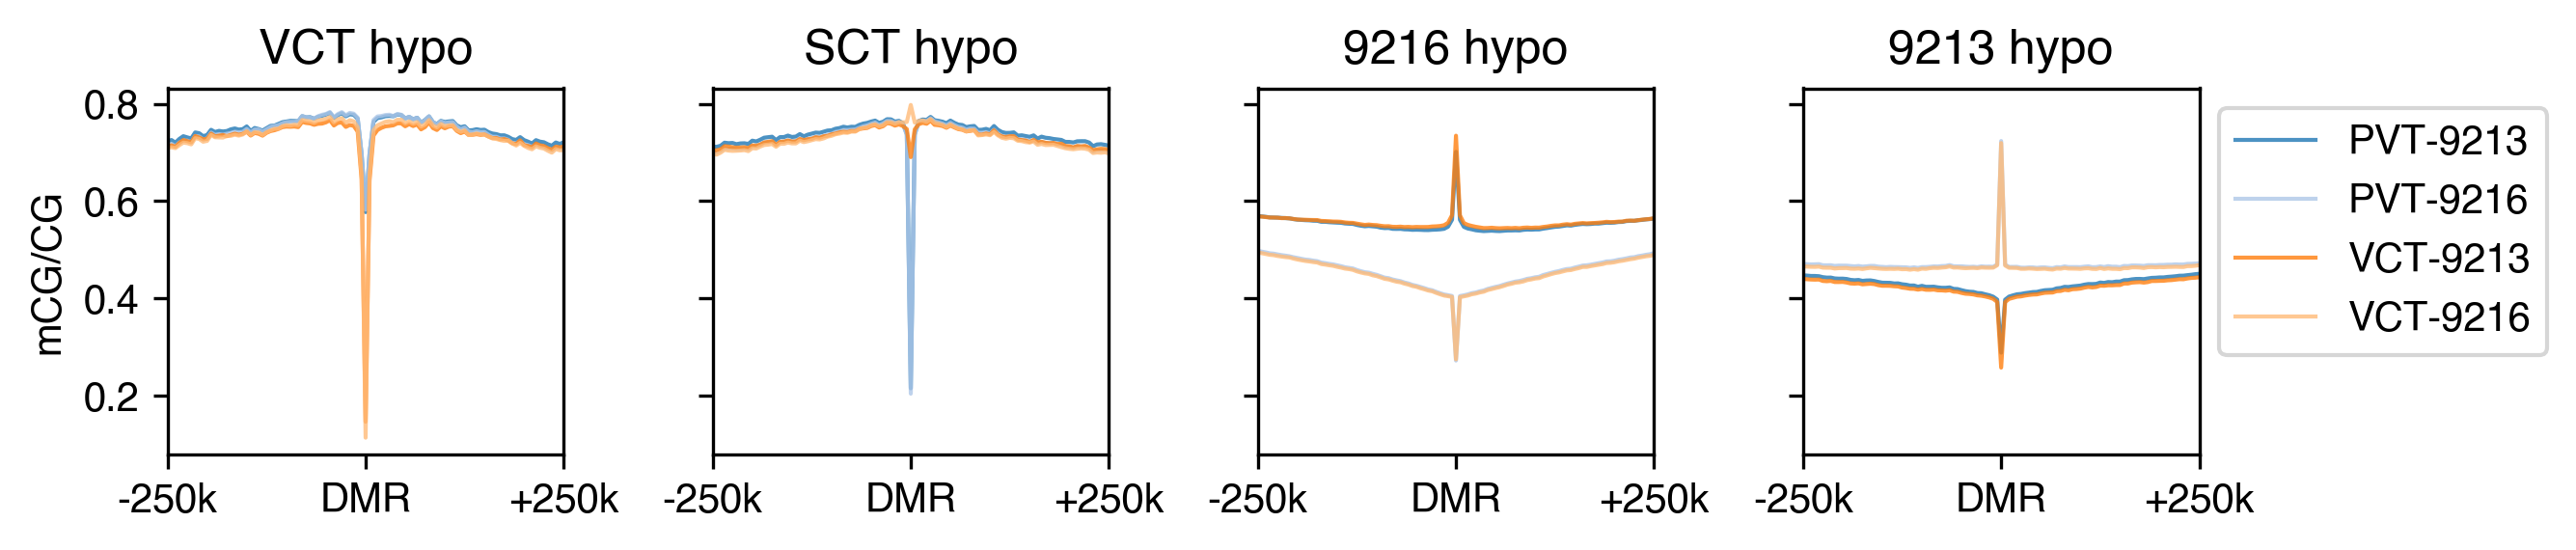

In [77]:
titles = ['VCT hypo', 'SCT hypo', '9216 hypo', '9213 hypo']

fig, axes = plt.subplots(1, 4, figsize=(9,2), dpi=300, sharey='all', sharex='all')
for i,peak_ct in enumerate(dmr_list):
    for k in range(2):
        ax = axes[i*2+k]
        if k*2+i%2==0:
            ax.set_ylabel('mCG/CG')
        for j,mc_ct in enumerate(bw_list):
            ax.plot(np.arange(101), ave_list[i][k][j], color=plt.cm.tab20(j), 
                    label=mc_ct.split('/')[-1], linewidth=1, alpha=0.8)
        ax.set_title(titles[i*2+k])

ax.set_xlim([0, 100])
ax.set_xticks([0, 50, 100])
ax.set_xticklabels(['-250k', 'DMR', '+250k'])
ax.legend(bbox_to_anchor=(1,1))

fig.tight_layout()
fig.savefig(f'{outdir}{group_name}_DMR_flank_lineplot.pdf', transparent=True)
